# Modelagem e Predição

Etapas:
1. Carregar dados processados
2. Baseline com Cross-Validation (5 modelos)
3. Hyperparameter Tuning do melhor modelo
4. Predição final e geração de submission

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier,
    ExtraTreesClassifier, 
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Carregar Dados

In [2]:
# Carrega dados concatenados (com nameseq)
df_train = pd.read_csv("../data/processed/train_combined_features.csv")
print(f"Train shape: {df_train.shape}")
print(f"Distribuição de classes:\n{df_train['label'].value_counts()}")

# Separa features e target
X_train = df_train.drop(columns=['nameseq', 'label'])
y_train = df_train['label']

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Amostras: {X_train.shape[0]}")

# Carrega dados de teste
df_test = pd.read_csv("../data/processed/test_combined_features.csv")
print(f"Test shape: {df_test.shape}")

X_test = df_test.drop(columns=['nameseq'])
test_ids = df_test['nameseq']

print(f"Test IDs shape: {len(test_ids)}")

Train shape: (3880, 502)
Distribuição de classes:
label
0    1940
1    1940
Name: count, dtype: int64

Features: 500
Amostras: 3880
Test shape: (970, 501)
Test IDs shape: 970


In [16]:
## 1.5. Análise e Pré-processamento das Features

# Análise básica das features
print("=== ANÁLISE DAS FEATURES ===")
print(f"Shape: {X_train.shape}")
print(f"Features com valores nulos: {X_train.isnull().sum().sum()}")
print(f"Range das features:")
print(f"  Min: {X_train.min().min():.6f}")
print(f"  Max: {X_train.max().max():.6f}")
print(f"  Média: {X_train.mean().mean():.6f}")
print(f"  Std: {X_train.std().mean():.6f}")

# Verifica se há features com variância zero
zero_var_features = X_train.columns[X_train.var() == 0]
if len(zero_var_features) > 0:
    print(f"\nFeatures com variância zero: {len(zero_var_features)}")
    X_train = X_train.drop(columns=zero_var_features)
    X_test = X_test.drop(columns=zero_var_features)
    print(f"Shape após remoção: {X_train.shape}")

# REMOVIDO: Etapa de scaling dos dados
# Mantemos as features na escala original para melhor compatibilidade com tree-based models
print(f"\n=== USANDO FEATURES NA ESCALA ORIGINAL ===")
print(f"Dados shape: {X_train.shape}")


=== ANÁLISE DAS FEATURES ===
Shape: (3880, 500)
Features com valores nulos: 0
Range das features:
  Min: -1.000000
  Max: 1741.000000
  Média: 1.608977
  Std: 2.312608

=== USANDO FEATURES NA ESCALA ORIGINAL ===
Dados shape: (3880, 500)


## 2. Baseline - Cross-Validation

In [21]:
# === BASELINE: Teste de múltiplos modelos com CV ===

# Configuração do Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário de modelos (APENAS TREE-BASED E ENSEMBLE)
models = {
    'LightGBM': LGBMClassifier(
        n_estimators=100, 
        random_state=42, 
        verbose=-1,
        n_jobs=-1, 
        force_col_wise=True
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        random_state=42,
        verbose=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    ),
    # NOVOS MODELOS ENSEMBLE/TREE-BASED
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    'Histogram GB': HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    )
}

# Armazena resultados
results = []

print("Treinando modelos TREE-BASED com 5-Fold Cross-Validation...\n")

for name, model in models.items():
    print(f"Treinando {name}...")
    
    # Cross-validation com múltiplas métricas - USANDO DADOS ORIGINAIS
    scores_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    scores_roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    results.append({
        'Modelo': name,
        'Accuracy': scores_acc.mean(),
        'Accuracy_std': scores_acc.std(),
        'F1-Score': scores_f1.mean(),
        'F1_std': scores_f1.std(),
        'ROC-AUC': scores_roc.mean(),
        'ROC_std': scores_roc.std()
    })
    
    print(f"Accuracy: {scores_acc.mean():.4f} (±{scores_acc.std():.4f})")
    print(f"F1-Score: {scores_f1.mean():.4f} (±{scores_f1.std():.4f})")
    print(f"ROC-AUC:  {scores_roc.mean():.4f} (±{scores_roc.std():.4f})\n")

Treinando modelos TREE-BASED com 5-Fold Cross-Validation...

Treinando LightGBM...
Accuracy: 0.8528 (±0.0085)
F1-Score: 0.8514 (±0.0091)
ROC-AUC:  0.9309 (±0.0058)

Treinando XGBoost...
Accuracy: 0.8510 (±0.0064)
F1-Score: 0.8501 (±0.0069)
ROC-AUC:  0.9286 (±0.0046)

Treinando CatBoost...
Accuracy: 0.8363 (±0.0086)
F1-Score: 0.8358 (±0.0095)
ROC-AUC:  0.9167 (±0.0065)

Treinando Random Forest...
Accuracy: 0.8268 (±0.0024)
F1-Score: 0.8247 (±0.0040)
ROC-AUC:  0.9133 (±0.0052)

Treinando AdaBoost...
Accuracy: 0.7296 (±0.0135)
F1-Score: 0.7047 (±0.0201)
ROC-AUC:  0.8136 (±0.0120)

Treinando Extra Trees...
Accuracy: 0.8446 (±0.0048)
F1-Score: 0.8413 (±0.0054)
ROC-AUC:  0.9275 (±0.0063)

Treinando Gradient Boosting...
Accuracy: 0.8332 (±0.0104)
F1-Score: 0.8312 (±0.0101)
ROC-AUC:  0.9108 (±0.0052)

Treinando Histogram GB...
Accuracy: 0.8539 (±0.0061)
F1-Score: 0.8526 (±0.0064)
ROC-AUC:  0.9311 (±0.0041)



In [22]:
# Resultados em tabela
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC-AUC', ascending=False)
print("Resultados do Baseline (ordenado por ROC-AUC):\n")
print(df_results.to_string(index=False))

Resultados do Baseline (ordenado por ROC-AUC):

           Modelo  Accuracy  Accuracy_std  F1-Score   F1_std  ROC-AUC  ROC_std
     Histogram GB  0.853866      0.006132  0.852594 0.006431 0.931126 0.004102
         LightGBM  0.852835      0.008525  0.851380 0.009138 0.930853 0.005783
          XGBoost  0.851031      0.006448  0.850075 0.006909 0.928591 0.004579
      Extra Trees  0.844588      0.004794  0.841253 0.005412 0.927521 0.006256
         CatBoost  0.836340      0.008587  0.835821 0.009465 0.916746 0.006490
    Random Forest  0.826804      0.002390  0.824676 0.004001 0.913332 0.005219
Gradient Boosting  0.833247      0.010425  0.831225 0.010103 0.910781 0.005160
         AdaBoost  0.729639      0.013550  0.704739 0.020070 0.813594 0.011965


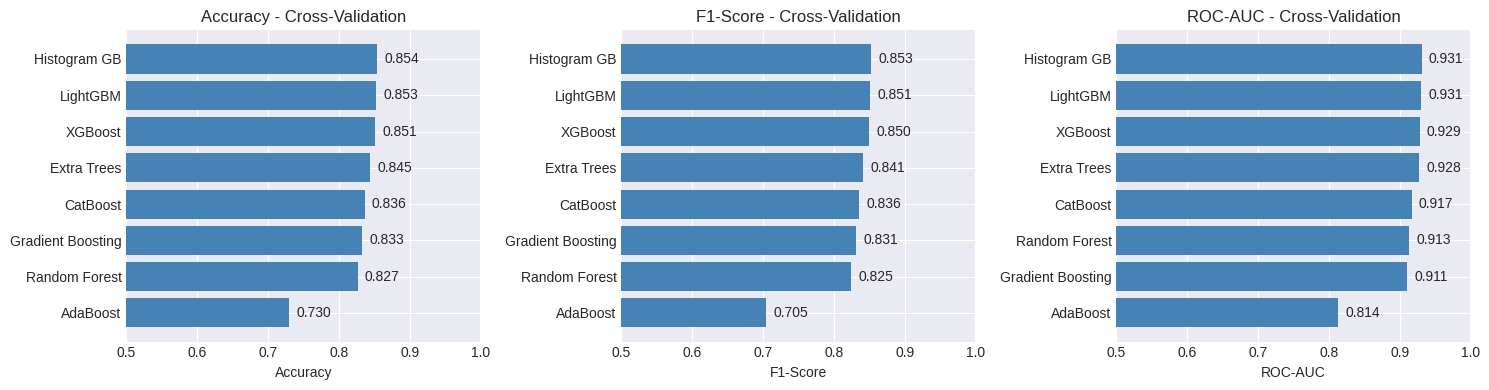


Melhor modelo (por ROC-AUC): Histogram GB


In [23]:
# Visualização
import os
os.makedirs('../data/processed', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(['Accuracy', 'F1-Score', 'ROC-AUC']):
    ax = axes[idx]
    df_plot = df_results.sort_values(metric, ascending=True)
    ax.barh(df_plot['Modelo'], df_plot[metric], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} - Cross-Validation')
    ax.set_xlim([0.5, 1.0])
    
    # Adiciona valores nas barras
    for i, v in enumerate(df_plot[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMelhor modelo (por ROC-AUC): {df_results.iloc[0]['Modelo']}")

In [28]:
## 3. Hyperparameter Tuning Avançado - Todos os Modelos Tree-Based

import optuna
from sklearn.model_selection import cross_val_score

print("\n" + "="*80)
print("HYPERPARAMETER TUNING AVANÇADO - TODOS OS TREE-BASED MODELS")
print("="*80)

# Função objetivo para cada modelo
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.3, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'verbose': -1,
        'force_col_wise': True,
        'n_jobs': -1
    }
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_histgb(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_bins': trial.suggest_int('max_bins', 32, 255),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 1.0),
        'random_state': 42
    }

    model = HistGradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

# Configuração de otimização (diferentes níveis de prioridade)
optimization_config = {
    'LightGBM': {'func': objective_lgbm, 'trials': 100, 'timeout': 1800},
    'XGBoost': {'func': objective_xgb, 'trials': 100, 'timeout': 1800}, 
    'Histogram GB': {'func': objective_histgb, 'trials': 100, 'timeout': 1800},
}

optimized_models = {}
optimized_scores = {}
baseline_scores = {}

# Pega scores baseline para comparação
for result in results:
    baseline_scores[result['Modelo']] = result['Accuracy']

print(f"Otimizando {len(optimization_config)} modelos tree-based...")

for model_name, config in optimization_config.items():
    print(f"\nOtimizando {model_name}...")
    print(f"   Trials: {config['trials']}, Timeout: {config['timeout']}s")
    
    study = optuna.create_study(
        direction='maximize', 
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=10)
    )
    
    study.optimize(
        config['func'], 
        n_trials=config['trials'], 
        timeout=config['timeout'],
        show_progress_bar=True
    )
    
    baseline_score = baseline_scores.get(model_name, 0)
    improvement = (study.best_value - baseline_score) * 100
    
    print(f"{model_name}:")
    print(f"   Baseline:    {baseline_score:.4f}")
    print(f"   Otimizado:   {study.best_value:.4f}")
    print(f"   Melhoria:    {improvement:+.2f}%")
    print(f"   Status:      {'Excelente!' if improvement > 2.0 else 'Boa melhoria' if improvement > 0.5 else '~ Marginal' if improvement > 0 else 'Pior'}")
    
    optimized_scores[model_name] = study.best_value
    optimized_models[model_name] = study.best_params

# Ranking final
print(f"\n{'='*80}")
print("RANKING FINAL - MODELOS OTIMIZADOS")
print(f"{'='*80}")

sorted_models = sorted(optimized_scores.items(), key=lambda x: x[1], reverse=True)

for i, (model_name, score) in enumerate(sorted_models, 1):
    baseline_score = baseline_scores.get(model_name, 0)
    improvement = (score - baseline_score) * 100
    
    print(f"{i}. {model_name}: {score:.4f} (melhoria: {improvement:+.2f}%)")

print(f"\nTOP 3 OTIMIZADOS:")
top3_optimized = [name for name, _ in sorted_models[:3]]
for i, name in enumerate(top3_optimized, 1):
    score = optimized_scores[name]
    print(f"  {i}. {name}: {score:.4f}")

print(f"\nTodos os modelos otimizados salvos para ensemble!")

[I 2025-11-18 17:46:25,447] A new study created in memory with name: no-name-f3a959df-e7a5-4617-92d0-ef874628b70c



HYPERPARAMETER TUNING AVANÇADO - TODOS OS TREE-BASED MODELS
Otimizando 3 modelos tree-based...

Otimizando LightGBM...
   Trials: 100, Timeout: 1800s


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-18 17:46:31,792] Trial 0 finished with value: 0.8603092783505154 and parameters: {'n_estimators': 331, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'feature_fraction': 0.7190609389379257, 'bagging_fraction': 0.4936111842654619, 'min_child_samples': 19, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.8603092783505154.
[I 2025-11-18 17:46:41,787] Trial 1 finished with value: 0.8448453608247423 and parameters: {'n_estimators': 501, 'max_depth': 12, 'learning_rate': 0.010725209743171997, 'feature_fraction': 0.978936896513396, 'bagging_fraction': 0.899465584480253, 'min_child_samples': 25, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 0.8603092783505154.
[I 2025-11-18 17:46:46,368] Trial 2 finished with value: 0.8515463917525773 and parameters: {'n_estimators': 278, 'max_depth': 9, 'learning_rate': 0.04345454109729477, 'feature_fraction': 0.5038603981386294, 'bagging

[I 2025-11-18 17:59:47,414] A new study created in memory with name: no-name-bd9afbb8-5285-4ea8-9c2f-7337ff408a92


...

[I 2025-11-18 17:59:52,817] Trial 0 finished with value: 0.8463917525773196 and parameters: {'n_estimators': 331, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.40921304830970556, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124, 'min_child_weight': 9}. Best is trial 0 with value: 0.8463917525773196.
[I 2025-11-18 18:00:16,773] Trial 1 finished with value: 0.8497422680412372 and parameters: {'n_estimators': 501, 'max_depth': 12, 'learning_rate': 0.010725209743171997, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.8827098485602951, 'reg_alpha': 0.0070689749506246055, 'reg_lambda': 0.005337032762603957, 'min_child_weight': 2}. Best is trial 1 with value: 0.8497422680412372.
[I 2025-11-18 18:00:22,300] Trial 2 finished with value: 0.85 and parameters: {'n_estimators': 278, 'max_depth': 9, 'learning_rate': 0.04345454109729477, 'subsample': 0.645614570099021, 'colsample_bytree': 0.7282970263056656, '

[I 2025-11-18 18:23:14,764] A new study created in memory with name: no-name-8f4c030f-783a-42f1-a727-2742803557c5


[I 2025-11-18 18:23:14,762] Trial 99 finished with value: 0.8603092783505154 and parameters: {'n_estimators': 638, 'max_depth': 13, 'learning_rate': 0.03342781881676654, 'subsample': 0.5722718282800832, 'colsample_bytree': 0.8881525561125966, 'reg_alpha': 0.7011984526846595, 'reg_lambda': 0.4691419672354224, 'min_child_weight': 1}. Best is trial 66 with value: 0.8652061855670103.
XGBoost:
   Baseline:    0.8510
   Otimizado:   0.8652
   Melhoria:    +1.42%
   Status:      ✓ Boa melhoria

Otimizando Histogram GB...
   Trials: 100, Timeout: 1800s


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-18 18:23:19,212] Trial 0 finished with value: 0.8628865979381445 and parameters: {'max_iter': 250, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'max_bins': 166, 'min_samples_leaf': 12, 'l2_regularization': 0.15599452033620265}. Best is trial 0 with value: 0.8628865979381445.
[I 2025-11-18 18:23:22,159] Trial 1 finished with value: 0.8512886597938145 and parameters: {'max_iter': 123, 'max_depth': 14, 'learning_rate': 0.07725378389307355, 'max_bins': 190, 'min_samples_leaf': 5, 'l2_regularization': 0.9699098521619943}. Best is trial 0 with value: 0.8628865979381445.
[I 2025-11-18 18:23:25,592] Trial 2 finished with value: 0.8365979381443298 and parameters: {'max_iter': 433, 'max_depth': 5, 'learning_rate': 0.01855998084649059, 'max_bins': 73, 'min_samples_leaf': 18, 'l2_regularization': 0.5247564316322378}. Best is trial 0 with value: 0.8628865979381445.
[I 2025-11-18 18:23:27,844] Trial 3 finished with value: 0.8492268041237114 and parameters: {'max_iter': 273, 'max_

## 2.1. Ensemble dos Top 3 Modelos (por Acurácia)

Vamos criar um ensemble por votação ponderada dos 3 melhores modelos baseado em **Acurácia** (métrica do Kaggle)

In [29]:
## 4. Ensemble dos Top 3 Modelos OTIMIZADOS

from sklearn.ensemble import VotingClassifier

print("\n" + "="*60)
print("ENSEMBLE DOS TOP 3 MODELOS OTIMIZADOS")
print("="*60)

# Seleciona top 3 por BALANCED ACCURACY dos modelos otimizados
top3_optimized_names = [name for name, _ in sorted_models[:3]]  # ← da otimização

print(f"\nTop 3 modelos otimizados:")
for i, name in enumerate(top3_optimized_names, 1):
    score = optimized_scores[name]
    print(f"  {i}. {name}: {score:.4f}")

# Cria os modelos OTIMIZADOS COMPLETOS
ensemble_models_optimized = []

for name in top3_optimized_names:
    print(f"\nConfigurando {name} (OTIMIZADO)...")
    
    if name == 'LightGBM':
        model = LGBMClassifier(**optimized_models[name])
    elif name == 'XGBoost':
        model = XGBClassifier(**optimized_models[name])
    elif name == 'CatBoost':
        model = CatBoostClassifier(**optimized_models[name])
    elif name == 'Random Forest':
        model = RandomForestClassifier(**optimized_models[name])
    elif name == 'Histogram GB':
        model = HistGradientBoostingClassifier(**optimized_models[name])
    elif name == 'Extra Trees':
        model = ExtraTreesClassifier(**optimized_models[name])
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(**optimized_models[name])
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(**optimized_models[name])
    else:
        print(f"Modelo {name} não reconhecido, pulando...")
        continue
    
    ensemble_models_optimized.append((name.lower().replace(' ', ''), model))
    print(f" {name} otimizado adicionado ao ensemble")

# Verifica se há modelos suficientes
if len(ensemble_models_optimized) < 2:
    print("Erro: Menos de 2 modelos válidos para ensemble!")
    # Fallback para melhor modelo individual
    best_model_name = top3_optimized_names[0]
    print(f"Usando melhor modelo individual: {best_model_name}")
    
    if best_model_name == 'LightGBM':
        final_model = LGBMClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'XGBoost':
        final_model = XGBClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'CatBoost':
        final_model = CatBoostClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'Random Forest':
        final_model = RandomForestClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'Histogram GB':
        final_model = HistGradientBoostingClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'Extra Trees':
        final_model = ExtraTreesClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'AdaBoost':
        final_model = AdaBoostClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'Gradient Boosting':
        final_model = GradientBoostingClassifier(**optimized_models[best_model_name])
    
    final_model_name = f"{best_model_name}-Otimizado"
    final_accuracy = optimized_scores[best_model_name]
    final_data = X_train
    
else:
    # Cria ensemble otimizado
    ensemble_optimized = VotingClassifier(
        estimators=ensemble_models_optimized,
        voting='soft',
        n_jobs=-1
    )

    print(f"\nTestando ensemble otimizado com {len(ensemble_models_optimized)} modelos...")
    scores_acc_opt = cross_val_score(ensemble_optimized, X_train, y_train, cv=cv, scoring='balanced_accuracy')

    print(f"\nRESULTADO ENSEMBLE OTIMIZADO:")
    print(f"  Ensemble Otimizado: {scores_acc_opt.mean():.4f} (±{scores_acc_opt.std():.4f})")

    # Compara ensemble vs melhor individual otimizado
    best_individual_optimized = max(optimized_scores.values())
    improvement_ensemble = (scores_acc_opt.mean() - best_individual_optimized) * 100

    print(f"\nCOMPARAÇÃO: ENSEMBLE vs MELHOR INDIVIDUAL OTIMIZADO")
    print(f"{'='*50}")
    print(f"Melhor individual otimizado: {best_individual_optimized:.4f}")
    print(f"Ensemble otimizado:          {scores_acc_opt.mean():.4f}")
    print(f"Melhoria do ensemble:        {improvement_ensemble:+.2f}%")
    print(f"Status:                      {'Ensemble melhor!' if improvement_ensemble > 0 else 'Individual melhor'}")

    # Escolhe entre ensemble ou melhor individual
    if scores_acc_opt.mean() > best_individual_optimized:
        print(f"\nVENCEDOR: ENSEMBLE OTIMIZADO")
        final_model = ensemble_optimized
        final_model_name = f"Ensemble-Otimizado({'+'.join(top3_optimized_names)})"
        final_accuracy = scores_acc_opt.mean()
        final_data = X_train
    else:
        print(f"\nVENCEDOR: MELHOR INDIVIDUAL OTIMIZADO")
        best_name = max(optimized_scores, key=optimized_scores.get)
        
        if best_name == 'LightGBM':
            final_model = LGBMClassifier(**optimized_models[best_name])
        elif best_name == 'XGBoost':
            final_model = XGBClassifier(**optimized_models[best_name])
        elif best_name == 'CatBoost':
            final_model = CatBoostClassifier(**optimized_models[best_name])
        elif best_name == 'Random Forest':
            final_model = RandomForestClassifier(**optimized_models[best_name])
        elif best_name == 'Histogram GB':
            final_model = HistGradientBoostingClassifier(**optimized_models[best_name])
        elif best_name == 'Extra Trees':
            final_model = ExtraTreesClassifier(**optimized_models[best_name])
        elif best_name == 'AdaBoost':
            final_model = AdaBoostClassifier(**optimized_models[best_name])
        elif best_name == 'Gradient Boosting':
            final_model = GradientBoostingClassifier(**optimized_models[best_name])
        
        final_model_name = f"{best_name}-Otimizado"
        final_accuracy = optimized_scores[best_name]
        final_data = X_train

print(f"\nMODELO FINAL SELECIONADO:")
print(f"Nome: {final_model_name}")
print(f"Balanced Accuracy (CV): {final_accuracy:.4f}")


ENSEMBLE DOS TOP 3 MODELOS OTIMIZADOS

Top 3 modelos otimizados:
  1. LightGBM: 0.8686
  2. Histogram GB: 0.8673
  3. XGBoost: 0.8652

Configurando LightGBM (OTIMIZADO)...
 LightGBM otimizado adicionado ao ensemble

Configurando Histogram GB (OTIMIZADO)...
 Histogram GB otimizado adicionado ao ensemble

Configurando XGBoost (OTIMIZADO)...
 XGBoost otimizado adicionado ao ensemble

Testando ensemble otimizado com 3 modelos...
[LightGBM] [Warning] feature_fraction is set=0.4747441259963481, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4747441259963481
[LightGBM] [Warning] bagging_fraction is set=0.7984071054202734, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7984071054202734
[LightGBM] [Warning] feature_fraction is set=0.4747441259963481, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4747441259963481
[LightGBM] [Warning] bagging_fraction is set=0.7984071054202734, subsample=1.0 will be ignored. Current value: bagg

## 2.3. Predição e Submission com Modelo Final

In [30]:
## 5. Predição Final e Submission com Modelo Otimizado

print("\n" + "="*60)
print("PREDIÇÃO FINAL COM MODELO OTIMIZADO")
print("="*60)

# Configurações finais
X_test_final = X_test
print(f"Dados de treino: {X_train.shape}")
print(f"Dados de teste:  {X_test_final.shape}")

# Verifica compatibilidade das features
if X_train.shape[1] != X_test_final.shape[1]:
    print("ERRO: Incompatibilidade de features entre treino e teste!")
    print(f"  Treino: {X_train.shape[1]} features")
    print(f"  Teste:  {X_test_final.shape[1]} features")
    raise ValueError("Incompatibilidade de features!")

print(f"\nTreinando modelo final: {final_model_name}")
print(f"Balanced Accuracy esperada: {final_accuracy:.4f}")

# Treina com todos os dados de treino
final_model.fit(final_data, y_train)
print("Modelo treinado com sucesso!")

# Prediz no conjunto de teste
print("\nGerando predições...")
y_test_pred = final_model.predict(X_test_final)
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]  # Probabilidades classe 1

print(f"{len(y_test_pred)} predições geradas")

# Análise das predições
print(f"\n📊 ANÁLISE DAS PREDIÇÕES:")
print(f"Distribuição de classes preditas:")
print(f"  Classe 0 (Negativo): {(y_test_pred == 0).sum():,} ({(y_test_pred == 0).mean()*100:.1f}%)")
print(f"  Classe 1 (Positivo): {(y_test_pred == 1).sum():,} ({(y_test_pred == 1).mean()*100:.1f}%)")

print(f"\nEstatísticas das probabilidades:")
print(f"  Probabilidade média classe 1: {y_test_proba.mean():.3f}")
print(f"  Probabilidade mín classe 1:   {y_test_proba.min():.3f}")
print(f"  Probabilidade máx classe 1:   {y_test_proba.max():.3f}")
print(f"  Desvio padrão:                {y_test_proba.std():.3f}")

# Verifica distribuição vs baseline esperado
expected_pos_rate = y_train.mean()
actual_pos_rate = y_test_pred.mean()
distribution_diff = (actual_pos_rate - expected_pos_rate) * 100

print(f"\nVALIDAÇÃO DA DISTRIBUIÇÃO:")
print(f"Taxa classe 1 no treino:     {expected_pos_rate:.3f} ({expected_pos_rate*100:.1f}%)")
print(f"Taxa classe 1 nas predições: {actual_pos_rate:.3f} ({actual_pos_rate*100:.1f}%)")
print(f"Diferença:                   {distribution_diff:+.1f} pontos percentuais")
print(f"Status: {'Boa distribuição' if abs(distribution_diff) < 5 else 'Distribuição suspeita' if abs(distribution_diff) < 10 else 'Distribuição muito diferente'}")

# Cria submission
submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred
})

# Cria também versão com probabilidades (para análise)
submission_proba = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred,
    'PROBABILITY': y_test_proba
})

# Salva submissions
os.makedirs('../results', exist_ok=True)
submission_path = Path('../results/submission_optimized.csv')
submission_proba_path = Path('../results/submission_optimized_with_proba.csv')

submission.to_csv(submission_path, index=False)
submission_proba.to_csv(submission_proba_path, index=False)

print(f"\n{'='*60}")
print("SUBMISSIONS GERADAS COM SUCESSO!")
print(f"{'='*60}")
print(f"\nArquivos salvos:")
print(f"  Principal: {submission_path}")
print(f"  Com prob:  {submission_proba_path}")

print(f"\nRESUMO DO MODELO FINAL:")
print(f"  Modelo:              {final_model_name}")
print(f"  Balanced Accuracy:   {final_accuracy:.4f}")
print(f"  Gap para Top 1:      {(0.9057 - final_accuracy)*100:.2f}%")
print(f"  Total predições:     {len(submission):,}")

print(f"\nPrimeiras 10 predições:")
print(submission.head(10).to_string(index=False))


PREDIÇÃO FINAL COM MODELO OTIMIZADO
Dados de treino: (3880, 500)
Dados de teste:  (970, 500)

Treinando modelo final: LightGBM-Otimizado
Balanced Accuracy esperada: 0.8686
Modelo treinado com sucesso!

Gerando predições...
970 predições geradas

📊 ANÁLISE DAS PREDIÇÕES:
Distribuição de classes preditas:
  Classe 0 (Negativo): 490 (50.5%)
  Classe 1 (Positivo): 480 (49.5%)

Estatísticas das probabilidades:
  Probabilidade média classe 1: 0.498
  Probabilidade mín classe 1:   0.000
  Probabilidade máx classe 1:   1.000
  Desvio padrão:                0.473

VALIDAÇÃO DA DISTRIBUIÇÃO:
Taxa classe 1 no treino:     0.500 (50.0%)
Taxa classe 1 nas predições: 0.495 (49.5%)
Diferença:                   -0.5 pontos percentuais
Status: Boa distribuição

SUBMISSIONS GERADAS COM SUCESSO!

Arquivos salvos:
  Principal: ../results/submission_optimized.csv
  Com prob:  ../results/submission_optimized_with_proba.csv

RESUMO DO MODELO FINAL:
  Modelo:              LightGBM-Otimizado
  Balanced Accurac